## Smart Location Database
-  Google Drive Link: https://drive.google.com/drive/folders/1brJHl3erkNzy_dTF98I82eG5_jvUhwgU?usp=sharing
-  Dataset Link: https://drive.google.com/drive/folders/1Q4iroaiCfD2w1STqbfoIRECa5Z5CT0Eo?usp=sharing
-  Variable Legend:
  https://geodata.epa.gov/arcgis/rest/services/OA/SmartLocationDatabase/MapServer/layers


#### NOTE: Due to GitHub size constraints, the database files cannot be uploaded onto Github. To access the dataset, use the "Google Drive Link" or "Dataset Link" above.

In [1]:
!pip install fiona
!pip install census

import os
import fiona
import geopandas as gpd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import math
from scipy.stats import boxcox
from census import Census
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [2]:
### ON DRIVE

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Path to your GDB file (update this path)
gdb_path = '/content/drive/MyDrive/Junior/INFO 3130/Final Project/Community - Connie/SLD.gdb'

# Check the layers available in the GDB
layers = fiona.listlayers(gdb_path)

# Read a specific layer (for example, the first one)
layer_name = layers[0]  # you can change this to any layer you want to load
smart_location_df = gpd.read_file(gdb_path, layer=layer_name)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
ny_smart_location_df = smart_location_df[smart_location_df['STATEFP'] == '36'].reset_index(drop=True)
ny_smart_location_df.set_index('GEOID20', inplace=True)
ny_smart_location_df.head()

,GEOID10,STATEFP,COUNTYFP,TRACTCE,BLKGRPCE,CSA,CSA_Name,CBSA,CBSA_Name,CBSA_POP,...,VMT_per_worker,VMT_tot_min,VMT_tot_max,VMT_tot_avg,GHG_per_worker,Annual_GHG,SLC_score,Shape_Length,Shape_Area,geometry
GEOID20,,,,,,,,,,,,,,,,,,,,,
360150102001,360150102001,36,015,010200,1,236,"Elmira-Corning, NY",21300,"Elmira, NY",85740.0,...,25.382988,7.690275,32.722666,19.519636,22.616242,5880.222946,29.320723,36464.422442,4.192845e+07,"MULTIPOLYGON (((1549562.097 2296224.275, 15495..."
360630243032,360630243032,36,063,024303,2,160,"Buffalo-Cheektowaga-Olean, NY",15380,"Buffalo-Cheektowaga, NY",1131570.0,...,23.194375,7.344131,28.629467,17.468909,20.666189,5373.209019,25.534440,22887.021935,3.415362e+07,"MULTIPOLYGON (((1380986.983 2370657.447, 13809..."
360070143012,360070143012,36,007,014301,2,None,None,13780,"Binghamton, NY",243447.0,...,25.739532,9.909722,32.589187,20.926535,22.933923,5962.820031,30.202013,14968.354915,5.837457e+06,"MULTIPOLYGON (((1629494.517 2293876.766, 16294..."
360810259002,360810259002,36,081,025900,2,408,"New York-Newark, NY-NJ-CT-PA",35620,"New York-Newark-Jersey City, NY-NJ-PA",19318471.0,...,3.184032,1.032142,36.832113,11.177436,2.836972,737.612823,93.989129,1016.744396,6.461912e+04,"MULTIPOLYGON (((1833576.398 2184608.481, 18336..."
360810166002,360810166002,36,081,016600,2,408,"New York-Newark, NY-NJ-CT-PA",35620,"New York-Newark-Jersey City, NY-NJ-PA",19318471.0,...,5.948216,1.032142,36.832113,11.177436,5.299860,1377.963642,86.267939,1485.032311,9.137724e+04,"MULTIPOLYGON (((1842194.593 2179155.182, 18422..."




---



## Research Question:
### How does urban design (combination of land use diversity/density & street design) correlate with the accessibility of public transportation?


Variables:


* Urban Design
  * Density / Entropy & Land Use
    * D2B_E8MIX : 8-tier employment entropy (denominator set to observed employment types in the CBG)
    * D1A: Gross residential density (HU/acre) on unprotected land
    * D1B: Gross population density (people/acre) on unprotected land
    * D1C: Gross employment density (jobs/acre) on unprotected land
    * D2R_JOBPOP: Regional Diversity. Standard calculation based on population and total employment: Deviation of CBG ratio of jobs/pop from the regional average ratio of jobs/pop
  * Network Design
    * D5DRI: Regional Centrality Index of Transit
    * NatWalkInd: Walkability Index
    * D3A: Road Network Density
    * D3B: Street intersection density (weighted, auto-oriented intersections eliminated)
    * D4A: Distance from the population-weighted centroid to nearest transit stop (meters)

* Accessibility by Transit
  * D5DR: Proportional Accessibility of Regional Destinations by Transit (Employment accessibility expressed as a ratio of total MSA accessibility)


In [4]:
rqs_df = ny_smart_location_df[['D2B_E8MIX', 'D1A', 'D1B', 'D1C', 'D2R_JOBPOP', 'D5DRI', 'NatWalkInd', 'D3A', 'D3B', 'D4A', 'D5DR', 'geometry', 'COUNTYFP']]

rqs_df.head()

,D2B_E8MIX,D1A,D1B,D1C,D2R_JOBPOP,D5DRI,NatWalkInd,D3A,D3B,D4A,D5DR,geometry,COUNTYFP
GEOID20,,,,,,,,,,,,,
360150102001,0.956472,0.029261,0.078126,0.011395,0.254585,-99999.000000,5.166667,2.049676,1.092412,-99999.00,-99999.000000,"MULTIPOLYGON (((1549562.097 2296224.275, 15495...",015
360630243032,0.581794,0.075598,0.216960,0.012797,0.111398,-99999.000000,3.166667,2.197988,1.466803,-99999.00,-99999.000000,"MULTIPOLYGON (((1380986.983 2370657.447, 13809...",063
360070143012,0.802748,0.246363,0.574848,3.218809,0.303057,-99999.000000,8.166667,7.899193,14.398414,-99999.00,-99999.000000,"MULTIPOLYGON (((1629494.517 2293876.766, 16294...",007
360810259002,0.744217,28.056812,80.037065,57.240906,0.833942,0.506986,17.333333,25.424383,133.630585,242.74,0.000283,"MULTIPOLYGON (((1833576.398 2184608.481, 18336...",081
360810166002,0.560604,19.796932,69.444270,6.288958,0.166082,0.029180,14.333333,29.468186,113.378400,160.93,0.000016,"MULTIPOLYGON (((1842194.593 2179155.182, 18422...",081


In [5]:
## Removing Rows based on Constraints

# Create a boolean mask for each constraint
mask_D2B_E8MIX = (rqs_df['D2B_E8MIX'] >= 0) & (rqs_df['D2B_E8MIX'] <= 1)
mask_D1A = rqs_df['D1A'] >= 0
mask_D1B = rqs_df['D1B'] >= 0
mask_D1C = rqs_df['D1C'] >= 0
mask_D2R_JOBPOP = rqs_df['D2R_JOBPOP'] >= 0
mask_D5DRI = (rqs_df['D5DRI'] >= 0) & (rqs_df['D5DRI'] <= 1)
mask_NatWalkInd = (rqs_df['NatWalkInd'] >= 0) & (rqs_df['NatWalkInd'] <= 100)
mask_D3A = rqs_df['D3A'] >= 0
mask_D3B = rqs_df['D3B'] >= 0
mask_D4A = rqs_df['D4A'] >= 0
mask_D5DR = (rqs_df['D5DR'] >= 0) & (rqs_df['D5DR'] <= 1)

# Combine all masks using logical AND
combined_mask = mask_D2B_E8MIX & mask_D1A & mask_D1B & mask_D1C & mask_D2R_JOBPOP & mask_D5DRI & mask_NatWalkInd & mask_D3A & mask_D3B & mask_D4A & mask_D5DR

# Apply the combined mask to filter the DataFrame
filtered_rqs_df = rqs_df[combined_mask]
filtered_rqs_df = filtered_rqs_df[filtered_rqs_df['COUNTYFP'].isin(['005', '047', '061', '081', '085'])]
filtered_rqs_df

,D2B_E8MIX,D1A,D1B,D1C,D2R_JOBPOP,D5DRI,NatWalkInd,D3A,D3B,D4A,D5DR,geometry,COUNTYFP
GEOID20,,,,,,,,,,,,,
360810259002,0.744217,28.056812,80.037065,57.240906,0.833942,0.506986,17.333333,25.424383,133.630585,242.74,0.000283,"MULTIPOLYGON (((1833576.398 2184608.481, 18336...",081
360810166002,0.560604,19.796932,69.444270,6.288958,0.166082,0.029180,14.333333,29.468186,113.378400,160.93,0.000016,"MULTIPOLYGON (((1842194.593 2179155.182, 18422...",081
360811227021,0.000000,53.666938,131.824297,0.000000,0.000000,0.154780,9.666667,15.441301,59.517861,301.75,0.000086,"MULTIPOLYGON (((1841416.643 2184722.706, 18413...",081
360810283005,0.890368,137.710892,286.833683,18.544335,0.121452,0.535719,10.833333,21.479258,0.000000,178.37,0.000299,"MULTIPOLYGON (((1835042.223 2185641.317, 18351...",081
360811483004,0.803865,4.776298,12.819061,2.221196,0.295367,0.082963,15.333333,27.884708,205.067423,679.95,0.000046,"MULTIPOLYGON (((1845194.019 2190349.581, 18451...",081
...,...,...,...,...,...,...,...,...,...,...,...,...,...
360050224011,0.783742,58.616719,102.178197,4.442530,0.083333,0.374759,13.166667,32.795230,96.966754,189.10,0.000209,"MULTIPOLYGON (((1833701.206 2197324.153, 18337...",005
360050389001,0.520505,31.382071,101.026773,2.265551,0.043867,0.112753,13.666667,36.581654,179.042265,195.80,0.000063,"MULTIPOLYGON (((1832442.431 2197014.095, 18324...",005
360050071002,0.803682,13.084906,34.335869,25.439670,0.851173,0.205443,16.833333,25.903105,131.197999,387.58,0.000115,"MULTIPOLYGON (((1830847.089 2192066.92, 183090...",005


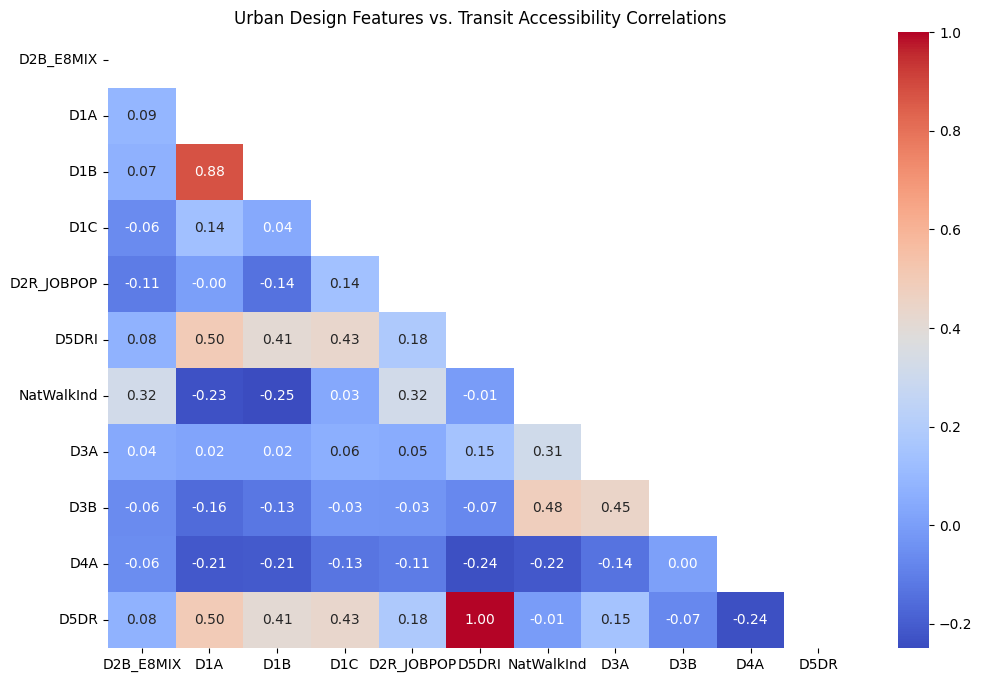

In [6]:
# Urban Design Variables
urban_design_vars = [
    'D2B_E8MIX',     # Land use diversity (employment entropy)
    'D1A',           # Residential density (housing units/acre)
    'D1B',           # Population density (people/acre)
    'D1C',           # Employment density (jobs/acre)
    'D2R_JOBPOP',    # Regional jobs-population balance
    'D5DRI',         # Transit centrality index
    'NatWalkInd',    # Walkability index
    'D3A',           # Road network density
    'D3B',           # Pedestrian-oriented intersection density
    'D4A',           # Distance to nearest transit stop
]

accessibility_var = 'D5DR'

# Heat Map -- Correlation Analysis
plt.figure(figsize=(12, 8))
corr_matrix = filtered_rqs_df[urban_design_vars + ['D5DR']].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm',
           mask=np.triu(np.ones_like(corr_matrix, dtype=bool)))
plt.title("Urban Design Features vs. Transit Accessibility Correlations")
plt.show()

<Figure size 1000x600 with 0 Axes>

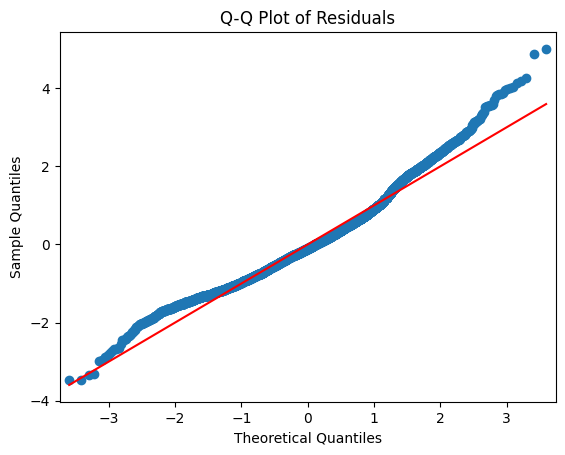

In [7]:
# Removal of Perfect Predictor Variable
  # D5DRI had a correlation of exactly 1.0, which is nearly which is impossible
  # in real-world data.
urban_design_vars.remove('D5DRI')

from scipy.stats import boxcox

# Fit initial model (from previous analysis)
X = sm.add_constant(filtered_rqs_df[urban_design_vars])
y_bc, lambda_ = boxcox(filtered_rqs_df['D5DR'] + 1)  # Add 1 to handle zeros
model = sm.OLS((y_bc), X).fit()

# Trim outliers
residuals = model.resid
threshold_low = residuals.quantile(0.01)
threshold_high = residuals.quantile(0.99)
df_filtered = filtered_rqs_df[(residuals >= threshold_low) & (residuals <= threshold_high)]
df_filtered = sm.add_constant(df_filtered)
model = sm.OLS(df_filtered['D5DR'], df_filtered[X.columns]).fit()

# Normality Check: Q-Q Plot
plt.figure(figsize=(10,6))
qqplot(model.resid, line='s', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

In [8]:
# Multicollinearity Check : VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                  for i in range(X.shape[1])]
print("\nVIF Scores:\n", vif_data)


VIF Scores:
      Variable        VIF
0       const  60.523501
1   D2B_E8MIX   1.410219
2         D1A   4.954174
3         D1B   4.819861
4         D1C   1.077262
5  D2R_JOBPOP   1.419620
6  NatWalkInd   2.336577
7         D3A   1.307063
8         D3B   1.788015
9         D4A   1.190471


In [9]:
# OLS Regression Analysis
X = sm.add_constant(filtered_rqs_df[urban_design_vars])  # Add intercept
y = filtered_rqs_df[accessibility_var]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   D5DR   R-squared:                       0.428
Model:                            OLS   Adj. R-squared:                  0.427
Method:                 Least Squares   F-statistic:                     519.9
Date:                Sun, 11 May 2025   Prob (F-statistic):               0.00
Time:                        22:05:08   Log-Likelihood:                 51317.
No. Observations:                6275   AIC:                        -1.026e+05
Df Residuals:                    6265   BIC:                        -1.025e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.449e-05   6.68e-06      8.160      0.0

In [10]:
# Coefficients (from OLS Regression Results)
coefficients = model.params.to_dict()

# Statistically Significant Variables (p <= 0.05)
statistically_significant_vars = list(coefficients.keys())
statistically_significant_vars.remove('D3B')
statistically_significant_vars.remove('const')

# Standardize
  # Variables are of different units or vastly different scales so standardization
  # is necessary (Prevents certain variables from dominating the composite score
  # simply because its raw values are orders of magnitude larger)
scaler = StandardScaler()
df_standardized = filtered_rqs_df[statistically_significant_vars + ['geometry']].copy()
df_standardized[statistically_significant_vars] = scaler.fit_transform(df_standardized[statistically_significant_vars])

In [11]:
# Compute Composite Score (Limited from 0 to 100 for Interpretability)
# Create composite score using only statistically significant variables
df_standardized['Composite'] = sum(
    df_standardized[var] * coefficients[var]
    for var in statistically_significant_vars
)

df_standardized['Composite_Score'] = (
    (df_standardized['Composite'] - df_standardized['Composite'].min()) /
    (df_standardized['Composite'].max() - df_standardized['Composite'].min()) * 100
)
df_standardized.head()

,D2B_E8MIX,D1A,D1B,D1C,D2R_JOBPOP,NatWalkInd,D3A,D4A,geometry,Composite,Composite_Score
GEOID20,,,,,,,,,,,
360810259002,0.301427,-0.393696,-0.274384,0.164299,2.110159,1.360187,-0.457603,0.075508,"MULTIPOLYGON (((1833576.398 2184608.481, 18336...",0.000112,83.802541
360810166002,-0.464680,-0.584805,-0.401041,-0.250430,-0.457855,0.204825,-0.074517,-0.499735,"MULTIPOLYGON (((1842194.593 2179155.182, 18422...",-0.000037,33.369724
360811227021,-2.803750,0.198849,0.344831,-0.301619,-1.096463,-1.592405,-1.403342,0.490433,"MULTIPOLYGON (((1841416.643 2184722.706, 18413...",-0.000133,0.658018
360810283005,0.911231,2.143382,2.198265,-0.150676,-0.629464,-1.143097,-0.831341,-0.377106,"MULTIPOLYGON (((1835042.223 2185641.317, 18351...",-0.000004,44.499762
360811483004,0.550306,-0.932339,-1.078104,-0.283540,0.039264,0.589945,-0.224526,3.149726,"MULTIPOLYGON (((1845194.019 2190349.581, 18451...",0.000016,51.107010


In [12]:
# Merge composite score with original data
filtered_rqs_df['D5DR'] = filtered_rqs_df['D5DR']
df_plot = filtered_rqs_df[['D5DR', 'D1B']].join(df_standardized[['Composite_Score']])
df_plot.head()

,D5DR,D1B,Composite_Score
GEOID20,,,
360810259002,0.000283,80.037065,83.802541
360810166002,0.000016,69.444270,33.369724
360811227021,0.000086,131.824297,0.658018
360810283005,0.000299,286.833683,44.499762
360811483004,0.000046,12.819061,51.107010


<ipython-input-13-a30884d296cb>:29: UserWarning: Mismatched number of handles and labels: len(handles) = 3 len(labels) = 4
  plt.legend(


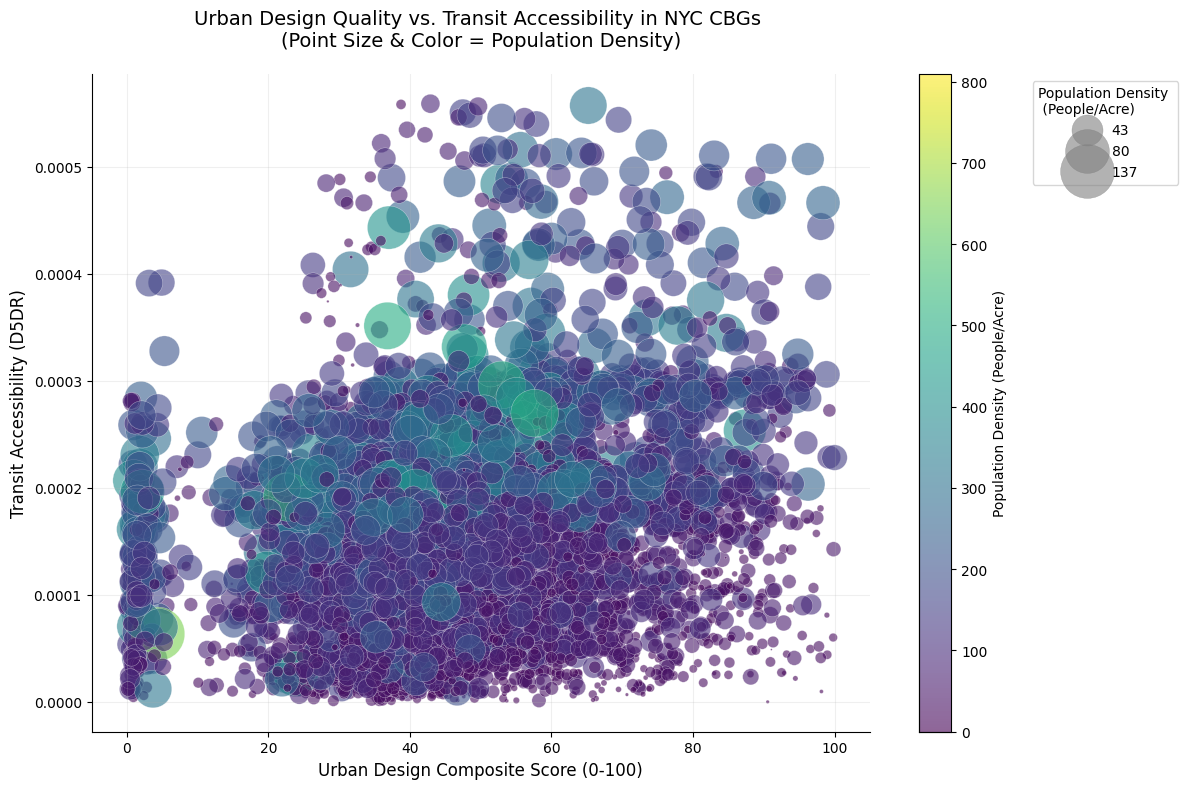

In [13]:
# Create figure
plt.figure(figsize=(12, 8))

# Create scatter plot with size mapping
scatter = plt.scatter(
    x='Composite_Score',
    y='D5DR',
    s=df_plot['D1B']/np.percentile(df_plot['D1B'], 90)*500,  # Scale sizes
    alpha=0.6,
    c=df_plot['D1B'],
    cmap='viridis',
    data=df_plot,
    edgecolor='w',
    linewidth=0.3
)

# Add labels and title
plt.xlabel('Urban Design Composite Score (0-100)', fontsize=12)
plt.ylabel('Transit Accessibility (D5DR)', fontsize=12)
plt.title('Urban Design Quality vs. Transit Accessibility in NYC CBGs \n(Point Size & Color = Population Density)', fontsize=14, pad=20)

# Add colorbar for density
cbar = plt.colorbar(scatter)
cbar.set_label('Population Density (People/Acre)', fontsize=10)

# Add size legend
sizes = [np.percentile(df_plot['D1B'], p) for p in [25, 50, 75, 90]]
labels = [f'{int(s)}' for s in sizes]
plt.legend(
    handles=scatter.legend_elements(prop="sizes", num=5, alpha=0.6, color='gray')[0],
    labels=labels,
    title="Population Density \n (People/Acre)",
    loc='upper left',
    bbox_to_anchor=(1.2, 1)
)

# Improve layout
plt.grid(alpha=0.2)
sns.despine()
plt.tight_layout()
plt.show()

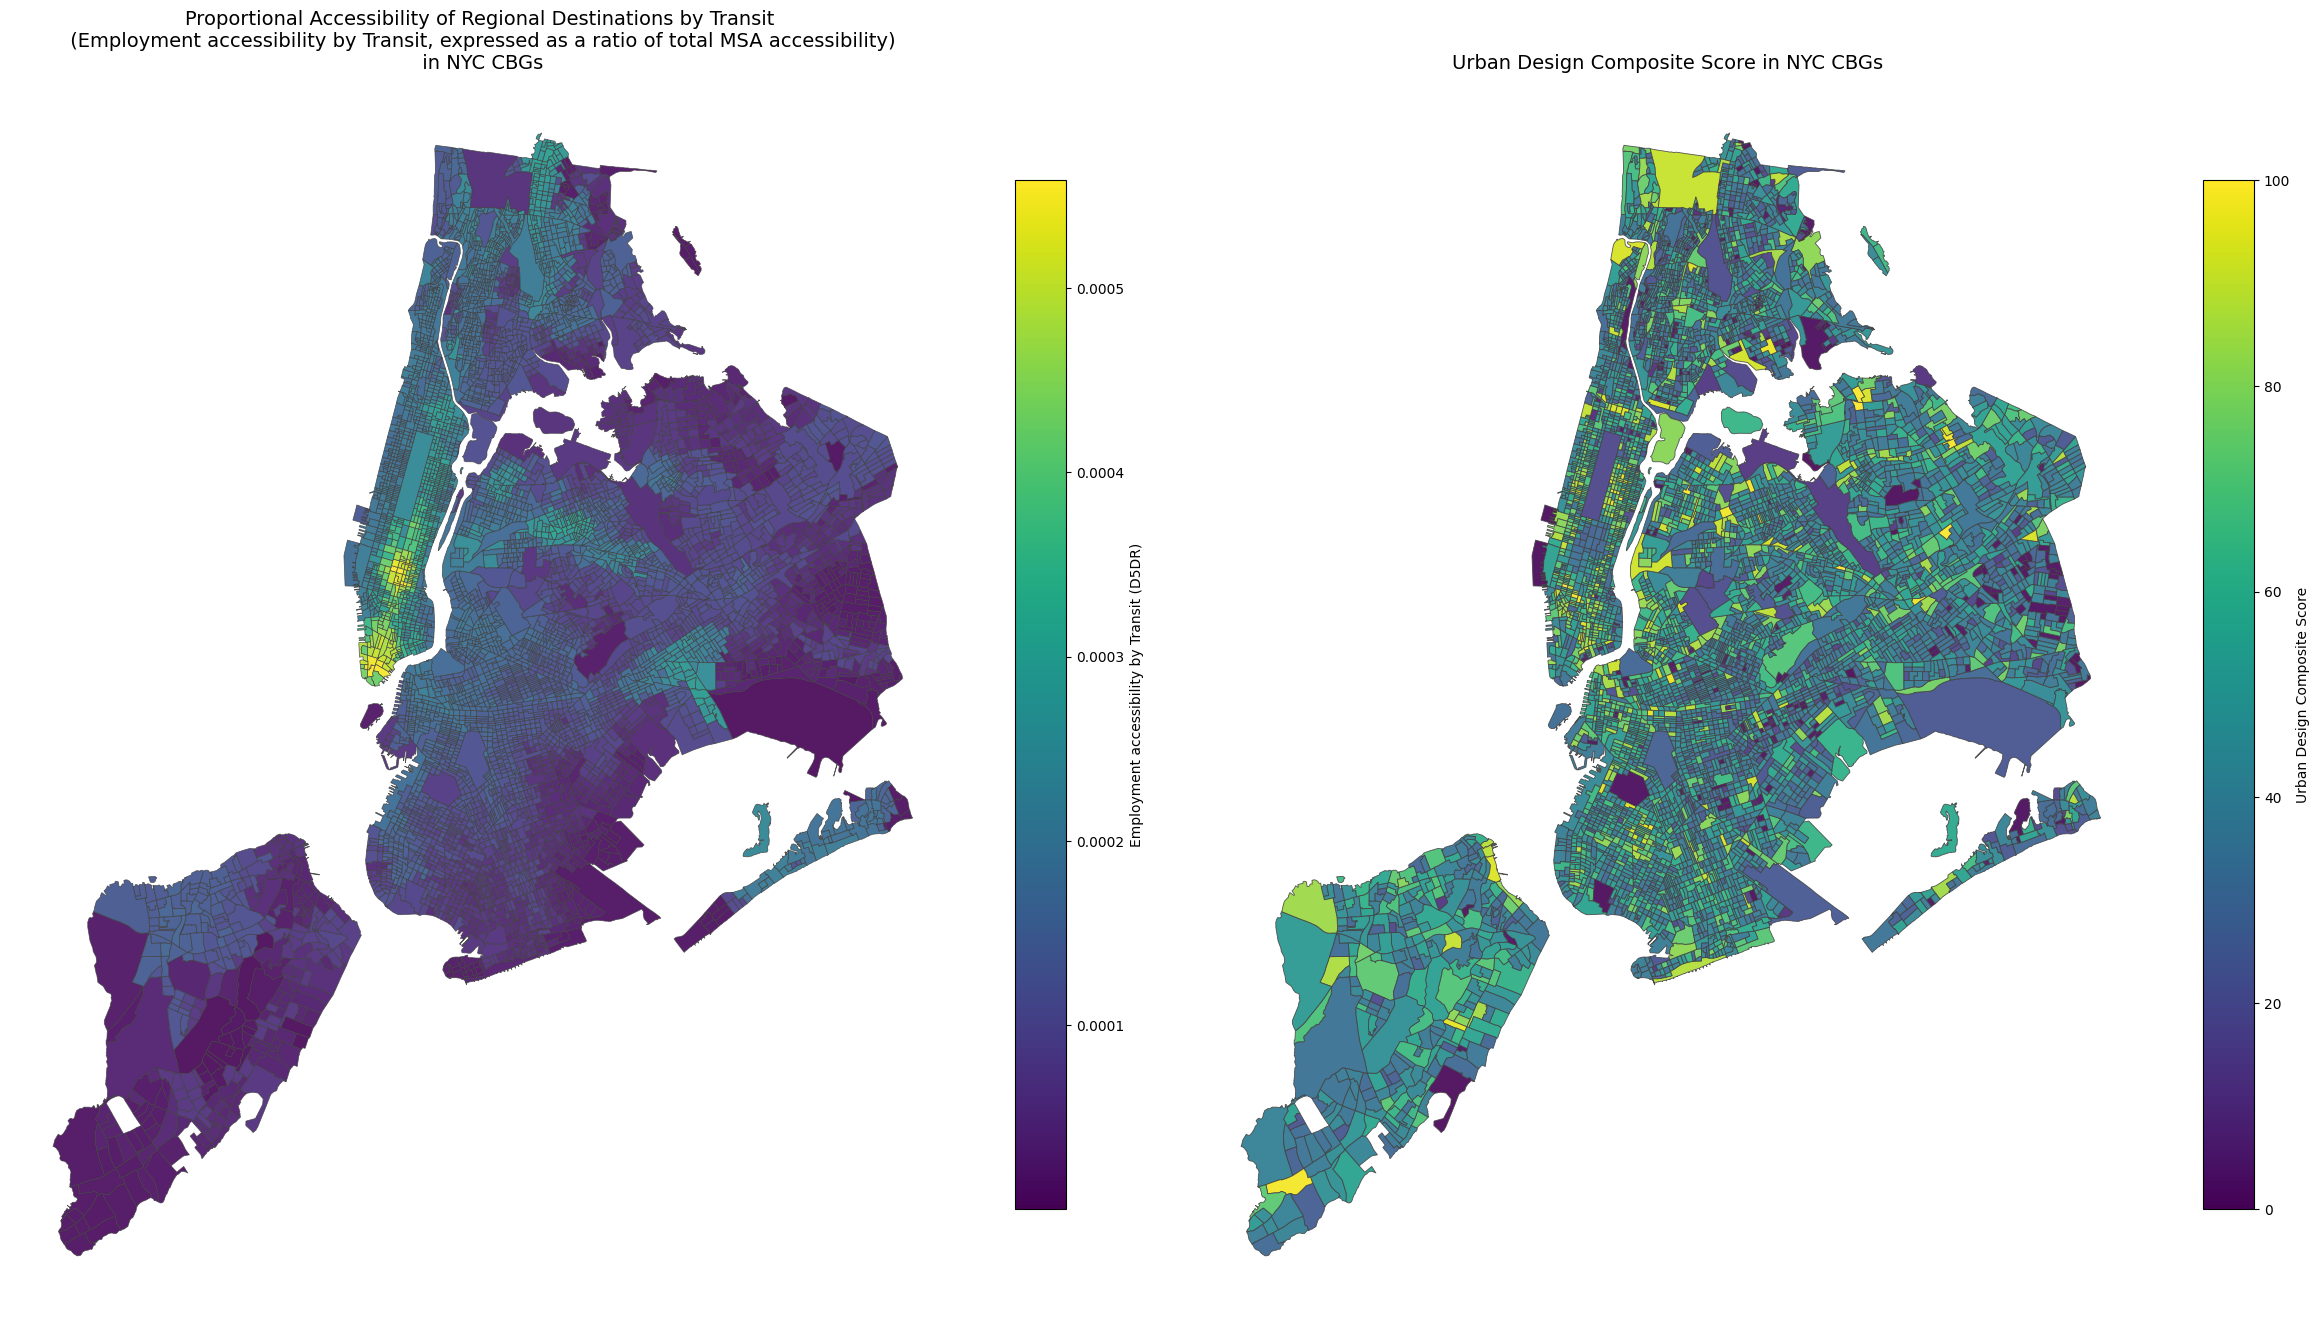

In [14]:
df_plot = filtered_rqs_df[['D5DR']].join(df_standardized[['Composite_Score', 'geometry']])
gdf = gpd.GeoDataFrame(df_plot, geometry='geometry')

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 15))

# First map: D5DR
gdf.plot(column='D5DR',
        ax=ax1,
        legend=True,
        legend_kwds={'label': "Employment accessibility by Transit (D5DR)", 'shrink': 0.7},
        cmap='viridis',
        edgecolor='#444444',
        linewidth=0.5,
        alpha=0.9)
ax1.set_title("Proportional Accessibility of Regional Destinations by Transit \n (Employment accessibility by Transit, expressed as a ratio of total MSA accessibility) \n in NYC CBGs ", fontsize=14)
ax1.axis('off')

# Second map: Composite Score
gdf.plot(column='Composite_Score',
        ax=ax2,
        legend=True,
        legend_kwds={'label': "Urban Design Composite Score", 'shrink': 0.7},
        cmap='viridis',
        edgecolor='#444444',
        linewidth=0.6,
        alpha=0.9)
ax2.set_title("Urban Design Composite Score in NYC CBGs ", fontsize=14)
ax2.axis('off')

# Adjust layout
plt.tight_layout()
plt.savefig('accessibility_composite_comparison.png', dpi=300, bbox_inches='tight')
plt.show()